# Networks in Epidemiology: Hantavirus

Network analysis is a fundamental tool for epidemiologists, particularly in the
study of infectious disease transmission, surveillance, and outbreak investigation.
Many data from such studies naturally lend themselves to graphical representations.
For instance, *contact tracing* involves the tracking of potential interactions
between members of a population who may have been exposed to disease.
It is natural to store such data in a graph where the nodes
represent individuals and the edges represent interactions (or potential interactions)
between them.
Another common type of graph is the *transmission network*, where the edges in
the graph represent transmissions (or possible transmissions) of an infectious
agent from one individual to another.
Such networks are powerful tools allowing epidemiologists to study and ultimately
predict the dynamics of infectious agents within populations.

## Studying an outbreak of Andes Hantavirus

In this tutorial, we will use NetworkX to investigate and reproduce results from an
epidemiological study of an outbreak in the Andes virus (ANDV) hantavirus that
occurred in 2018-2019: [“Super-Spreaders” and Person-to-Person Transmission of
Andes Virus in Argentina][paper] by Martínez, V. P. et. al.
The article is publicly available via the New England Journal of Medicine
[DOI: 10.1056/NEJMoa2009040][paper].

[paper]: https://www.nejm.org/doi/full/10.1056/NEJMoa2009040

The paper is packed with a ton of interesting information, but of particular
interest is the *transmission network* presented in Figure 1B:

```{figure} https://www.nejm.org/cms/10.1056/NEJMoa2009040/asset/af0da102-84a2-48bf-abec-b1660394b3ee/assets/images/large/nejmoa2009040_f1.jpg
:alt: Four-panel image summarizing study. Upper-right panel contains graphic of transmission network.
:align: center

Figure 1 from [the paper][paper]. Panel 1B presents the transmission network
that we recreate with NetworkX below.
```

Let's start by extracting the information from this figure into a NetworkX
graph!
For consistency, we'll use the same indexing scheme as the paper (i.e. the
initial patient will have index `1`).

In [1]:
import networkx as nx

G = nx.DiGraph()

# The initial infection of patients 2 through 6 (i.e. the top of the figure)
G.add_edges_from([(1, 2), (1, 3), (1, 4), (1, 5), (1, 6)])

# On to the second row, starting with the transmission from patient 2
G.add_edges_from([(2, 9), (2, 12), (2, 13), (2, 11), (2, 7), (2, 8)])
# and the transmissions to patients 14 and 10
G.add_edge(5, 14)
G.add_edge(2, 10)  # NOTE: see discussion below!

# On to the 3rd row, starting with those infected by patient 9
# fmt: off
G.add_edges_from(
    [
        (9, 15), (9, 16), (9, 17), (9, 18), (9, 19), (9, 22), (9, 23), (9, 24),
        (9, 27), (9, 30),
    ]
)
# fmt: on
# Patients 13, 8, and 14 each infected one other individual
G.add_edge(13, 25)
G.add_edge(8, 28)
G.add_edge(14, 26)
# And patient 10 - the details of which we will examine below
G.add_edges_from([(10, 20), (10, 21), (10, 29)])

# And finally, the last round of infection before the outbreak was halted
G.add_edges_from([(22, 31), (22, 33), (22, 34)])
G.add_edge(28, 32)

Now we have our transmission network!
Note however that we had to make some assumptions related to the "possible
transmissions", represented by the yellow arrows in figure 1B.
In the first row of the image, we see that any one of patients `2` through `6`
could've been the source of transmission to patient `10`.
From the supplementary material of the paper, we know that patient `10` was an
administrator in a healthcare center through which all 5 of these patients
passed.
For now, we dealt with this ambiguity by arbitrarily assigining the transmission
from one of the patients in the group (patient `2` in this case) to patient `10`.
Similarly, there are possible transmissions between patients within subgroups
later on in the outbreak (cf. patients `20` and `31`).
For now we've chosen to ignore these possible transmissions.
We will investigate alternatives later on in the tutorial.

Also note that we've chosen to represent the network as a `DiGraph` - i.e. to
use directed edges to capture the tranmissions.
This is a natural choice for disease transmission as we can model the
direction of transmission (*from* patient X *to* patient Y) with the direction
of the edge.

## Examining the Transmission Network

First things first - let's visualize the network:

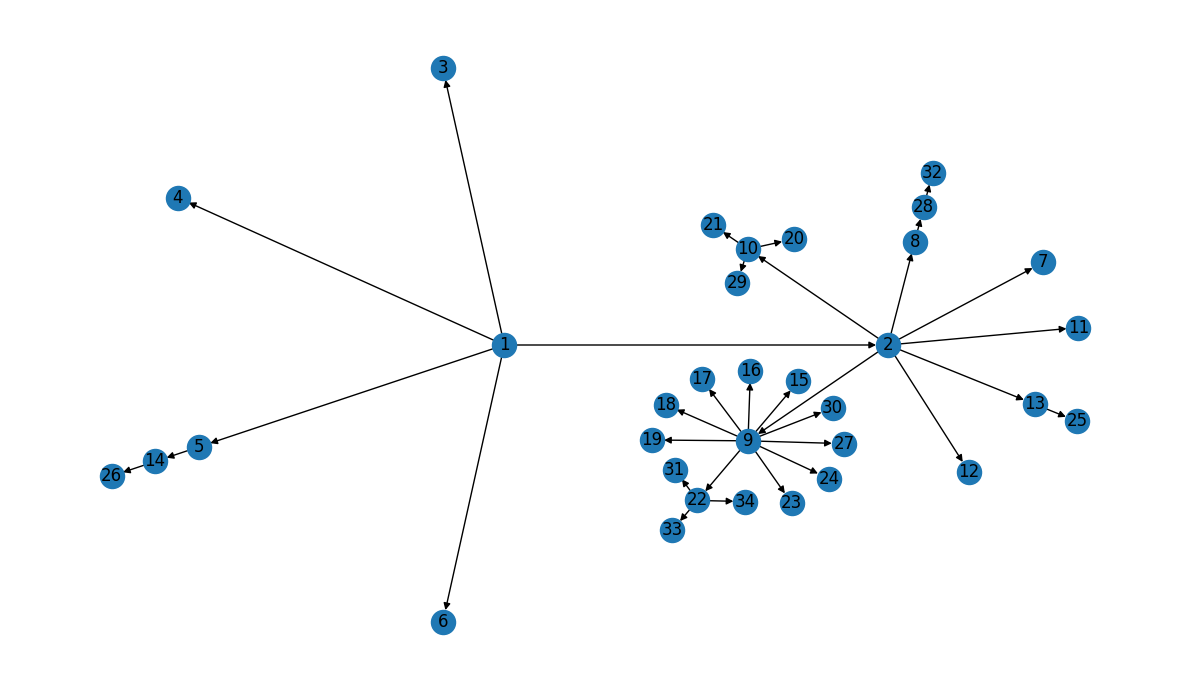

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 7))

circo_pos = nx.nx_agraph.graphviz_layout(G, prog="circo", args="")
nx.draw(G, circo_pos, ax=ax, with_labels=True)
fig.tight_layout()

Our layout looks a little different than the graph in Figure 1B, but the
transmission information appears to be correct... Let's double-check!

### Validation

First - we know there are 34 total patients, so let's make sure we didn't miss
any:

In [3]:
len(G) == 34

True

The `Z` values along the edges in Figure 1B represent the total number of
known transmissions from a given patient.
In our directed network, this corresponds to the `out_degree` of the nodes.
Let's compare the `out_degree` for our patients to the Z-values listed in
Figure 1B, starting with the "super-spreaders":

In [4]:
G.out_degree(1) == 5 and G.out_degree(9) == 10

True

Recall that, in our graph, we arbitrarily assigned patient `2` as the
transmission source for patient `10`, so we'd expect patient `2` to have an
out-degree of 7 instead of 6 as shown in the figure:

In [5]:
G.out_degree(2) == 7

True

Similarly, we ignored the "possible sources" in our model, so both patients
`10` and `22` should have out-degree 3:

In [6]:
G.out_degree(10) == 3 and G.out_degree(22) == 3

True

The remaining patients who transimitted the infection (i.e. all other red patients
in figure 1B) did so to only 1 other patient:

In [7]:
remaining_transmitters = [5, 13, 8, 14, 28]
all(G.out_degree[n] == 1 for n in remaining_transmitters)

True

And finally, the remaining patients in the network became infected, but did
not subsequently transmit the infection to anyone else[^1]:

[^1]: Recall that we're ignoring the possible transmissions from patient 20 and 31

In [8]:
# fmt: off
other_patients = [
    3, 4, 6, 12, 11, 7, 15, 16, 17, 18, 19, 23, 24, 27, 30, 25, 26, 20, 21, 29,
    31, 33, 34, 32
]
# fmt: on
all(G.out_degree[n] == 0 for n in other_patients)

True

Another thing we notice about this transmission network is that there are no
instances of "re-infection": there were no recorded cases in this dataset of a
patient who had previously been infected becoming infected again.
In other words, the transmission network should not contain any cycles and is
therefore a directed acyclic graph (DAG):

In [9]:
nx.is_directed_acyclic_graph(G)

True

Finally, the topology of the network reflects the reported "phases" of the
infection (roughly corresponding to the rows in figure 1B).
The first phase of the infection saw patient `1` transmit the infection to
patients `2` through `6`; the second phase comprises the transmissions from patients
`2` and `5` to patients `9` through `14`; etc.

In [10]:
# Mapping of the phase of the outbreak to patients infected in that phase
topo_layers = dict(enumerate(nx.topological_generations(G)))
topo_layers

{0: [1],
 1: [2, 3, 4, 5, 6],
 2: [9, 12, 13, 11, 7, 8, 10, 14],
 3: [15, 16, 17, 18, 19, 22, 23, 24, 27, 30, 25, 28, 20, 21, 29, 26],
 4: [31, 33, 34, 32]}

We can use this information to visualize the graph with a layout similar to
that in Figure 1B:

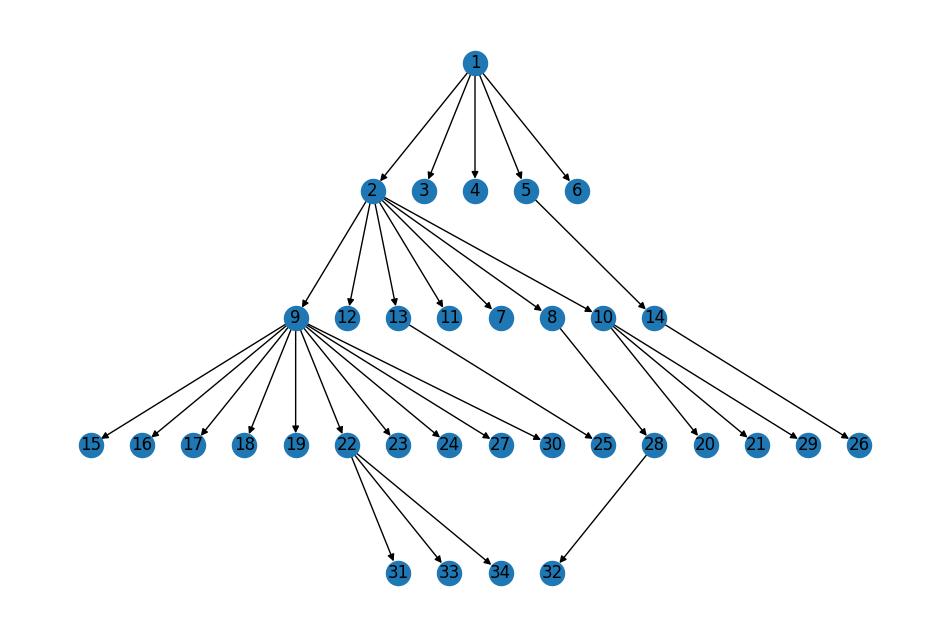

In [11]:
pos = nx.multipartite_layout(G, subset_key=topo_layers, align="horizontal")
# Flip the y-axis to put index patient at the top
topo_pos = {n: loc * (1, -1) for n, loc in pos.items()}

fig, ax = plt.subplots(figsize=(12, 8))
nx.draw(G, topo_pos, ax=ax, with_labels=True);

#### Summary

At this point we're confident that we have captured the basic structure of the
transmission network correctly.
Let's do one last round of visualization incorporating some of the additional
patient information; e.g. using color to encode whether a patient transmitted
the infection mimicing figure 1B:

```{figure} https://www.nejm.org/cms/10.1056/NEJMoa2009040/asset/af0da102-84a2-48bf-abec-b1660394b3ee/assets/images/large/nejmoa2009040_f1.jpg
:alt: A repeat of figure 1B.
:align: center

Figure 1B, repeated for easy comparison.
```

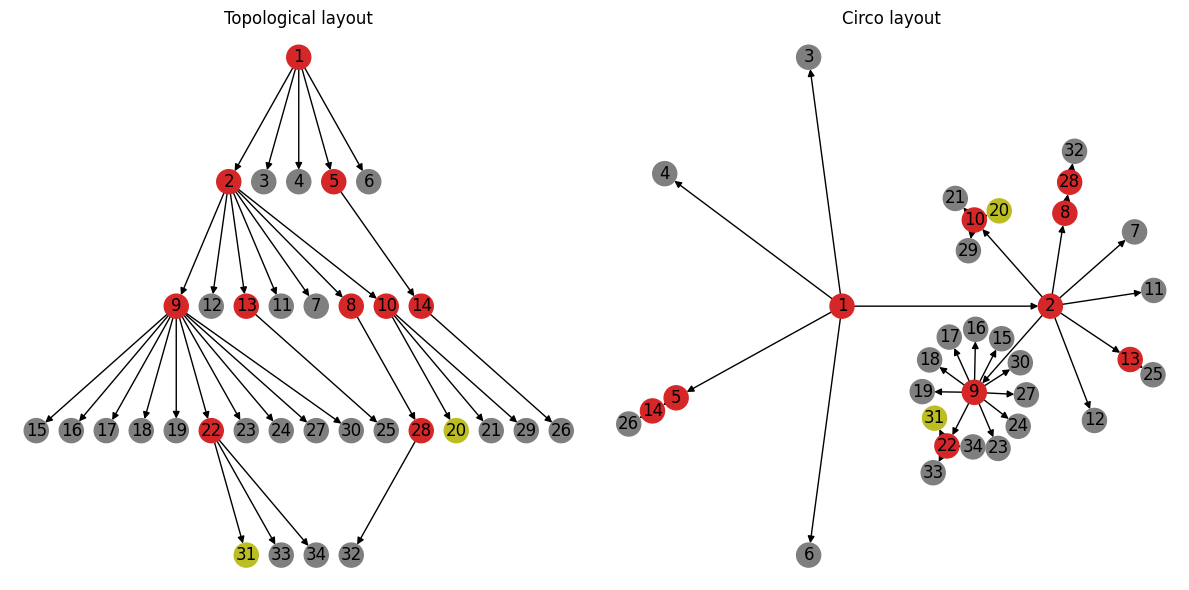

In [12]:
# Incorporate patient coloring from original figure
transmitters = {1, 2, 5, 9, 13, 8, 14, 10, 22, 28}
possible_transmitters = {20, 31}

# Attach some visualization attributes to our graph
for n in G:
    if n in transmitters:
        color = "tab:red"
    elif n in possible_transmitters:
        color = "tab:olive"
    else:
        color = "tab:gray"
    G.nodes[n]["color"] = color
nx.set_node_attributes(G, topo_pos, name="topo_pos")
nx.set_node_attributes(G, circo_pos, name="circo_pos")

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
nx.display(G, canvas=ax[0], node_pos="topo_pos")
nx.display(G, canvas=ax[1], node_pos="circo_pos")

# Format the image
for a, ttl in zip(ax.ravel(), ("Topological layout", "Circo layout")):
    a.set_title(ttl)
    a.set_axis_off()
fig.tight_layout()

Comparing these layouts side-by-side highlights the value of looking at the
same data from different perspectives.
The topological layout on the left highlights the progression of the
outbreak (i.e. who infected whom and in what order).
The layout on the right on the other hand highlights potential clusters based on
the degree of the transmission network.
For example, the super-spreader events (i.e. events resulting in transmitters with
out-degree greater than 3) are arguably more visually distinct in this layout.

## Computing $R_{0}$

The main goal of any modeling effort is to learn something about
the infection to inform decision makers and public health officials on how best
to respond.
One of the most well-known numbers associated with infectious transmission is the
*reproduction number*, $R_{0}$: a single parameter intended to
capture how transferable a disease is:

> $R_{0}$ is the average number of people that a single infectious person will
> infect over the course of their infection[^2]

[^2]: https://en.wikipedia.org/wiki/Mathematical_modelling_of_infectious_diseases#Reproduction_number

There are *many* different ways to model infectious disease, and therefore
there are many different ways to derive an estimate for $R_{0}$.

Thanks to the incredible work of the epidemiologists and researchers who
published the transmission network in this study, we can estimate
$R_{0}$ directly from the properties of the network.
From the [Wikipedia article on modeling epidemics on networks][wiki]:

[wiki]: https://en.wikipedia.org/wiki/Mathematical_modelling_of_infectious_diseases#Epidemic_Models_on_Networks

> In a transmission network, all the links are responsible for transmitting the disease.
> If such a network is a locally tree-like network, meaning that any local
> neighborhood in such a network takes the form of a tree, then the basic
> reproduction can be written in terms of the average excess degree of the
> transmission network such that:
> 
$$
R_{0} = \frac{\langle k^{2} \rangle}{\langle k \rangle} - 1
$$

> where $\langle k \rangle$ is the average degree of the network and
> $\langle k^{2} \rangle$ is the second moment of the transmission network
> degree distribution.

We've already established our transmission network is tree-like --- though we
modeled the network as a `DiGraph` (trees are undirected), we verified that
there were no cycles.
We can further verify by looking at an undirected version of our transmission
network:

In [13]:
SG = G.to_undirected()
nx.is_tree(SG)

True

Let's dive right in and apply the formula above directly to our data:

In [14]:
import numpy as np


def R0(G):
    """Compute R0 from the degree distribution of transmission network `G`"""
    deg = [d for _, d in G.degree]
    return np.var(deg) / np.mean(deg) - 1

In [15]:
print(f"{R0(G):.2f}")

1.39


The paper reports a posterior median $R$ value for the entire outbreak of
$1.19 \pm 0.37$ (95% credible interval).
Our computed $R_{0}$ deviates slightly from this estimate, but falls within the
reported interval[^3].
Note also the fairly wide credible interval reported in the paper.
Given the limited data available, it's not surprising that there is such a wide
range of statistically credible results.
All that said --- can we identify any possible sources of variability, and perhaps
come up with a way to probe the effects of uncertainty on our $R_{0}$ estimates?

[^3]: For details on the statistical analysis performed to estimate $R$ in the
paper, see both the `Methods` section and `Supplementary Appendix 1`.

### Revisiting our Assumptions

Recall that we made some arbitrary decisions when we were constructing our
transmission network from the information provided in Figure 1B; specifically
regarding how to deal with possible transmission.
For example, we know that patient `10` was exposed to each of patients `2` through `6`
and likely acquired the infection from one of those five candidates.
However, we do not know exactly which of these patients was the source of
infection in patient `10`.
For our initial model, we arbitrarily chose patient `2` as the the source.
What happens if we instead model patient `10`'s infection as having come from one
of the other candidates, say patient `3`?

In [16]:
# Keep a copy of the original transmission network model for comparison
G_orig = G.copy()

G.remove_edge(2, 10)
G.add_edge(3, 10)

print(f"{R0(G):.2f}")

1.21


That's a pretty significant swing in the estimated $R_{0}$ value!

Our updated transmission network model is not necessarily any more accurate
after this change; we replaced one arbitrarily selected edge with a different
one.
However - it does provide us with some sense of just how sensitive our $R_{0}$
estimate is to minor changes in the network.
It also presents us with a recipe to stochastically probe the uncertainty in
our model by modeling all possible transmission routes.

Is there another way we can capture these possible transmissions in our network?
One possibility would be to model possible transmissions with weighted edges,
where weights could represent e.g. the probability of transmission.
For example, let's say that patient `10` was equally likely to have become
infected from all of their possible exposures:

In [17]:
G.remove_edge(3, 10)

# Add edges for all possible infection sources for patient 10 with uniform probability
potential_trans_p10 = [(2, 10), (3, 10), (4, 10), (5, 10), (6, 10)]
p = 1 / len(potential_trans_p10)
G.add_weighted_edges_from((u, v, p) for u, v in potential_trans_p10)

We can now use the weighted degree to incorporate the possible transmissions
encoded by the edge weights.

In [18]:
def R0(G, weight=None):
    """Compute R0 from the weighted degree distribution of transmission network `G`"""
    deg = [d for _, d in G.degree(weight=weight)]
    return np.var(deg) / np.mean(deg) - 1

In [19]:
print(f"{R0(G, weight="weight"):.2f}")

1.24


Let's extend this pattern to the two other possible transmissions that we
ignored in the original model.

In [20]:
# Modify the transmissions from patient 10 to 20 and 29 to account for possible
# transmission from patient 20
G[10][29]["weight"] = 0.5
G.add_edge(20, 29, weight=0.5)

# And for patients 31, 33, and 34
G[22][33]["weight"] = 0.5
G[22][34]["weight"] = 0.5
G.add_weighted_edges_from([(31, 33, 0.5), (31, 34, 0.5)])

We're intending to use the edge weights to represent the probability of
transmission, so the total probability of any individual patient having become
infected (across all possible sources) should always be 1.
Therefore we can double-check we didn't make any data-entry mistakes by
verifying the `in_degree` of every node (excepting the index patient)
is 1.

In [21]:
all(d == 1 for _, d in G.in_degree(weight="weight", nbunch=(set(G) - {1})))

True

Looks good - let's see what effect these changes had on our modeled $R_{0}$:

In [22]:
print(f"{R0(G, weight="weight"):.2f}")

1.14


### Conclusion

Our simple replication of the $R_{0}$ estimate from [this study][paper]
(hopefully) provide a glimpse into the application of network analysis to
modeling infectious disease.
As with anything, the devil's in the details! Perhaps some questions come to mind:
 - We qualitatively probed uncertainties in our estimates through
   minor modifications to the modeled network. Are there more systematic approaches
   to quantify uncertainty?
 - We also assumed that the presented transmission network captured every
   transmission for this outbreak. What about incidents where this may not be
   the case; e.g. diseases where carriers don't necessarily exhibit symptoms or
   patients are missed during contact tracing? Can we capture/quantify such
   effects on our downstream estimates?
 - Our treatment of possible transmissions as edge weights introduces structure
   to the network that may have violated the "locally tree-like" assumption
   on which our $R_{0}$ calculation is based. How do we account for this?

In practice, more complex models with greater parametrization are required to
better capture uncertainties and the complexities of contact networks.
One thing this example should make abundantly clear is the importance of accurate
data and the utter necessity of boots-on-the-ground epidemiology in its collection.
The analysis reproduced here is only possible due to the high-quality
transmission network compiled by the researchers, which itself is the result of
meticulous case study and contact tracing.